# Case Study 2:
### Goals for notebook
- Labels = Days before game customer purchased

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from os import path 

import dotenv as de

from scipy.stats import pearsonr

# Load Data + Initial Exploration

In [15]:
DATASET_NAME = de.get_key(".env", "DATASET_NAME")

data = pd.read_excel(f"data/{DATASET_NAME}", sheet_name = [1,2]) #Load in the 2nd and 3rd sheets of the excel file (all other sheets contain metadata and are not relevant)

In [16]:
DATA_ORIGINAL = pd.concat([data[1], data[2]], axis=0, ignore_index=True)

In [17]:
#DATA_ORIGINAL.info(memory_usage='deep')

In [18]:
def preprocess_dataframe(df_orig):
    df = df_orig.copy()
    df['Fan_Mailing_List'] = df['Fan_Mailing_List'].map({"Yes" : True, "No" : False}).astype(bool)

    return df 

DATA = preprocess_dataframe(DATA_ORIGINAL)

# EDA

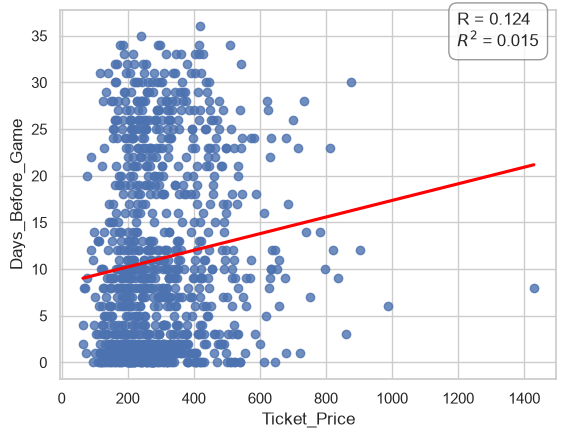

In [19]:
x = DATA['Ticket_Price']
y = DATA['Days_Before_Game']
r_value, _ = pearsonr(x, y)
r2_value = r_value**2

sns.set_theme(style="whitegrid")
ax = sns.regplot(x=x, y=y, ci=None, line_kws={"color" : "red"})
stats_text = f"R = {r_value:0.3f}\n$R^2$ = {r2_value:0.3f}"
plt.text(
    0.8, 0.9, stats_text,
    transform=ax.transAxes,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5')
)
plt.show()

### Does being on the mailing list influence the number of dates out the ticket purchase.

<Axes: xlabel='Fan_Mailing_List', ylabel='Days_Before_Game'>

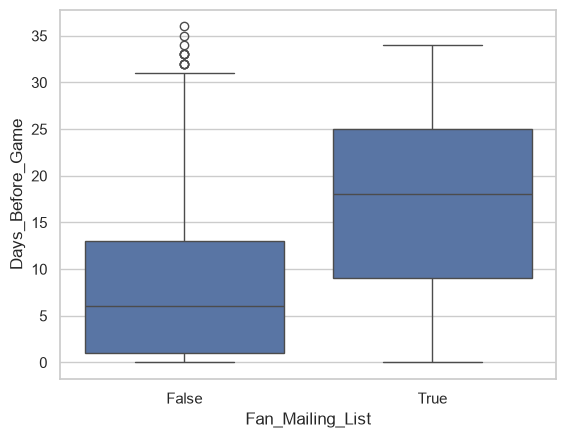

In [20]:
x = DATA['Fan_Mailing_List']
y = DATA['Days_Before_Game']
sns.boxplot(x=x, y=y)

**Remark:** On average, being on the mailing list on average causes patrons to purchase their tickets further out.

<Axes: xlabel='Seat_Location', ylabel='Days_Before_Game'>

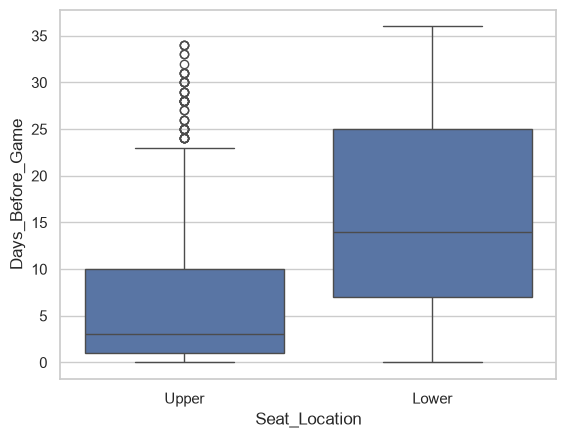

In [21]:
x = DATA['Seat_Location']
y = DATA['Days_Before_Game']
sns.boxplot(x=x, y=y)